In [ ]:
!pip install git+https://github.com/openai/CLIP.git
!pip install segment-anything opencv-python matplotlib

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-grspjiy7
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-grspjiy7
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.2 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=7812a295c6c84da3798acb70b84e6183213523516231b3809194104049f9dc0d
  Stored in directory: /tmp/pip-ephem-wheel-cache-gb_3aa88/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import torch
import clip
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model, preprocess = clip.load("ViT-B/32", device=device)

100%|███████████████████████████████████████| 338M/338M [00:07<00:00, 47.3MiB/s]


In [ ]:
image = Image.open("/content/crack.png")

input_image = preprocess(image).unsqueeze(0).to(device)

(np.float64(-0.5), np.float64(395.5), np.float64(393.5), np.float64(-0.5))

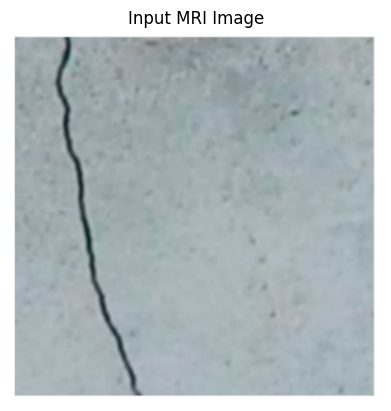

In [ ]:
plt.imshow(image)
plt.title("Input MRI Image")
plt.axis("off")

In [ ]:
text_prompts = [
"normal surface",
"crack surface"
]

text_tokens = clip.tokenize(text_prompts).to(device)

In [ ]:
with torch.no_grad():
    image_features = clip_model.encode_image(input_image)
    text_features = clip_model.encode_text(text_tokens)

print("Image feature shape:", image_features.shape)
print("Text feature shape:", text_features.shape)

Image feature shape: torch.Size([1, 512])
Text feature shape: torch.Size([2, 512])


In [ ]:
similarity = (image_features @ text_features.T).softmax(dim=-1)

print("Similarity scores:",similarity)

Similarity scores: tensor([[0.0592, 0.9409]], device='cuda:0', dtype=torch.float16)


(np.float64(-0.5), np.float64(395.5), np.float64(393.5), np.float64(-0.5))

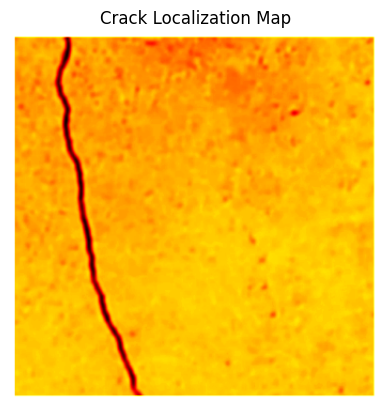

In [ ]:
img_cv = cv2.imread("/content/crack.png")
img_cv = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img_cv, cv2.COLOR_RGB2GRAY)

saliency_map = gray / gray.max()

plt.imshow(saliency_map, cmap="hot")
plt.title("Crack Localization Map")
plt.axis("off")

(np.float64(-0.5), np.float64(395.5), np.float64(393.5), np.float64(-0.5))

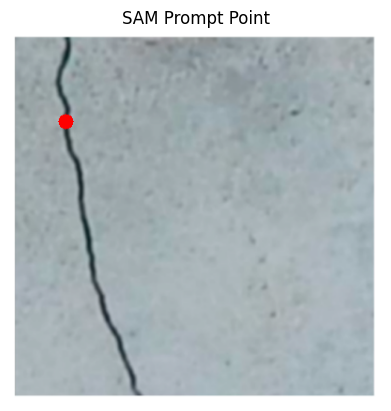

In [ ]:
y, x = np.unravel_index(np.argmin(saliency_map), saliency_map.shape)

point_coords = np.array([[x, y]])
point_labels = np.array([1])

img_point = img_cv.copy()

cv2.circle(img_point, (x, y), 8, (255,0,0), -1)

plt.imshow(img_point)
plt.title("SAM Prompt Point")
plt.axis("off")

In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-03-08 11:07:00--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.14, 3.163.189.108, 3.163.189.51, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b_01ec64.pth’

sam_vit_b_01ec64.pt 100%[===================>] 357.67M  29.4MB/s    in 6.6s    

2026-03-08 11:07:06 (54.5 MB/s) - ‘sam_vit_b_01ec64.pth’ saved [375042383/375042383]



In [ ]:
from segment_anything import sam_model_registry, SamPredictor

sam_checkpoint = "sam_vit_b_01ec64.pth"

sam_model = sam_model_registry["vit_b"](checkpoint=sam_checkpoint)

sam_model.to(device)

predictor = SamPredictor(sam_model)

In [ ]:
predictor.set_image(img_cv)

masks, scores, logits = predictor.predict(
    point_coords=point_coords,
    point_labels=point_labels,
    multimask_output=True
)
print("Number of masks:", len(masks))



Number of masks: 3


In [ ]:
best_mask = masks[np.argmax(scores)]

(np.float64(-0.5), np.float64(395.5), np.float64(393.5), np.float64(-0.5))

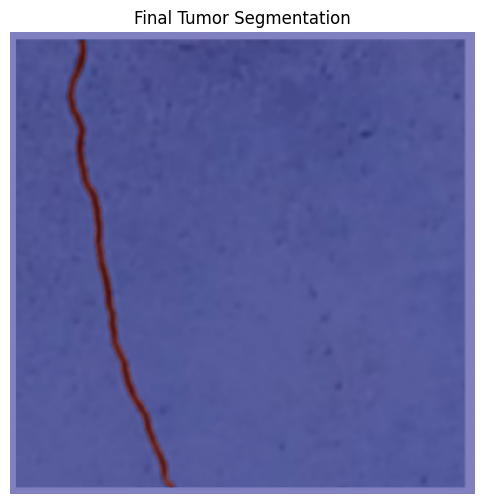

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(img_cv)
plt.imshow(best_mask, alpha=0.5, cmap="jet")

plt.title("Final Tumor Segmentation")
plt.axis("off")

(np.float64(-0.5), np.float64(395.5), np.float64(393.5), np.float64(-0.5))

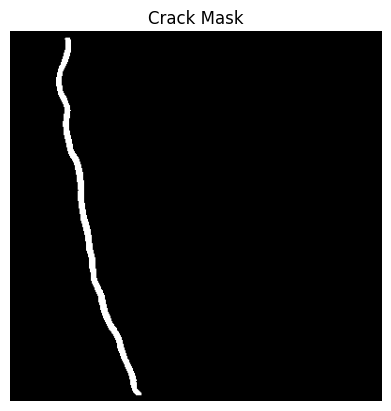

In [ ]:
plt.imshow(best_mask, cmap="gray")
plt.title("Crack Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(395.5), np.float64(393.5), np.float64(-0.5))

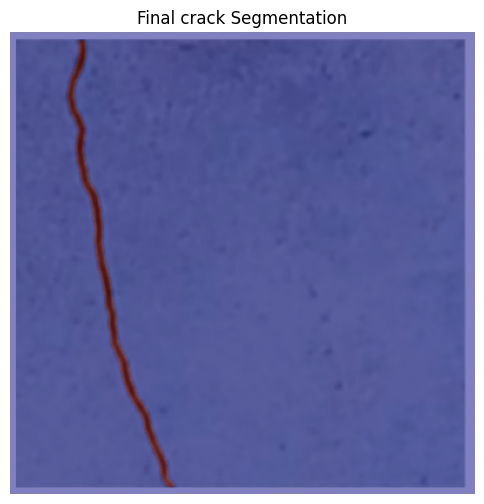

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(img_cv)
plt.imshow(best_mask, alpha=0.5, cmap="jet")

plt.title("Final crack Segmentation")
plt.axis("off")